# Unshared IRU-ACT (PPO): compute vs. performance

Compute-vs-performance pareto plots for the `lightsout_sweep-ppo_only` wandb project (`fetch_wandb_ppo_only_unshared_iru.py`), restricted to `network.actor_network.pre_torso._target_ == UnsharedIRUAdaptiveComputationTimeTorso` and `system.qac_variant == "reinforce"` - the only architecture/variant combo in that project, so there is a single column of results.

Each panel shows final performance vs. final compute steps: fixed-budget points (mean +/- SEM over seeds) as plain gray markers, plus one colored diamond for the adaptive[1-16] budget. On the discounted-return panels, dashed lines and a $\Delta$ box compare the adaptive budget against the best uniform budget.

Note: this project's `actor/*` episode metrics never include `compute_time` (see `fetch_wandb_ppo_only_unshared_iru.py`'s docstring), so `trainer/compute_time` is used as the x-axis for both the actor and evaluator panels.

Set `TRIM_N` to drop the N highest- and N lowest-performing seeds from each budget group before averaging (a trimmed mean/SEM), to keep one or two outlier seeds from dominating a group of only ~10.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter, NullLocator
from matplotlib.transforms import blended_transform_factory

import analysis_utils as base

set_size = base.set_size
pgf_with_latex = base.pgf_with_latex
doc_width_pt = base.doc_width_pt

plt.rcParams.update(pgf_with_latex)

CSV_PATH = "wandb_cache_ppo_only_unshared_iru.csv"
OUTPUT_DIR = Path("wandb_plots_ppo_only_unshared_iru")
SAVE_FIGS = True
TRIM_N = 0  # drop this many highest- and lowest-performing seeds per budget group before averaging
N_TAIL_EVALS = 3  # final performance = mean of the last N_TAIL_EVALS eval points

COMPUTE_METRIC = "trainer/compute_time"
# FS = dict(title=15, panel_title=13, label=13, tick=11, legend=11)

# Local label overrides - "Adaptive compute"/"Uniform compute" read more
# clearly on their own in this single-arch plot.
UNIFORM_LABEL = "Uniform compute"
ADAPTIVE_LABEL = {"reinforce": "Variable compute"}

In [2]:
df = pd.read_csv(CSV_PATH)
df = df[df["state"] == "finished"]

if SAVE_FIGS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SUFFIX = f"_trim{TRIM_N}" if TRIM_N > 0 else ""

print(f"runs={df['run_id'].nunique()}, seeds={df['seed'].nunique()}, trim={TRIM_N}")

runs=60, seeds=10, trim=0


## Helpers

`compute_final_values` reduces each run to one number (the tail-average of a metric), `_group_stats` turns a group of seeds into mean/SEM (after optional trimming), and `_draw_panel` draws one metric's pareto points onto an axis.

In [3]:
def compute_final_values(df, metric, n_tail=N_TAIL_EVALS):
    """Per-run final performance: mean of the last `n_tail` eval points, plus
    the run's budget/variant so it can be grouped on afterward."""
    tail = df.sort_values("eval_idx").groupby("run_id").tail(n_tail)
    return (
        tail.groupby("run_id")
        .agg(
            value=(metric, "mean"),
            arch=("arch", "first"),
            qac_variant=("qac_variant", "first"),
            min_steps=("min_steps", "first"),
            max_steps=("max_steps", "first"),
            sgh=("sgh", "first"),
            vocab_size=("vocab_size", "first"),
            seed=("seed", "first"),
        )
        .reset_index()
    )


def _trim_by_performance(g, trim):
    """Drops the `trim` seeds with the lowest and `trim` seeds with the
    highest `value_perf` from a (budget or qac_variant) group, so the
    reported mean/SEM is a trimmed statistic robust to one or two outlier
    seeds. No-op if there aren't enough seeds left over (need > 2*trim)."""
    if trim <= 0 or len(g) <= 2 * trim:
        return g
    return g.sort_values("value_perf").iloc[trim : len(g) - trim]


def _group_stats(g, trim):
    """(perf_mean, perf_sem, comp_mean, comp_sem, n) for one group, after
    trimming (see _trim_by_performance)."""
    g = _trim_by_performance(g, trim)
    n = len(g)
    perf_mean = g["value_perf"].mean()
    perf_sem = g["value_perf"].std() / np.sqrt(n) if n > 1 else 0.0
    comp_mean = g["value_compute"].mean()
    comp_sem = g["value_compute"].std() / np.sqrt(n) if n > 1 else 0.0
    return perf_mean, perf_sem, comp_mean, comp_sem, n


def _draw_panel(ax, df, metric, panel_label, show_ylabel, trim=0):
    """Draws one metric's uniform/adaptive-compute pareto points (plus, for
    the discounted-return metrics, the best-uniform-vs-adaptive delta
    annotation) onto `ax`. `trim` drops the `trim` highest- and
    lowest-performing seeds from each budget/variant group before averaging
    (see _trim_by_performance)."""
    qac_markers = {"reinforce": "D"}
    qac_colors = {"reinforce": sns.color_palette("colorblind", n_colors=3)[0]}
    fixed_color = "0.25"

    perf = compute_final_values(df, metric)
    comp = compute_final_values(df, COMPUTE_METRIC)
    merged = perf.merge(comp[["run_id", "value"]], on="run_id", suffixes=("_perf", "_compute"))

    fixed = merged[merged["min_steps"] == merged["max_steps"]]
    fixed_perf_means = {}
    if not fixed.empty:
        for i, (mn, g) in enumerate(sorted(fixed.groupby("min_steps"))):
            perf_mean, perf_sem, comp_mean, comp_sem, n = _group_stats(g, trim)
            fixed_perf_means[mn] = perf_mean
            ax.errorbar(
                [comp_mean],
                [perf_mean],
                xerr=[comp_sem],
                yerr=[perf_sem],
                marker="o",
                markersize=3,
                color=fixed_color,
                linestyle="none",
                # capsize=1,
                label=UNIFORM_LABEL if i == 0 else None,
            )

    adaptive = merged[merged["min_steps"] != merged["max_steps"]]
    adaptive_perf_means = {}
    for qac_variant, g in adaptive.groupby("qac_variant"):
        perf_mean, perf_sem, comp_mean, comp_sem, n = _group_stats(g, trim)
        adaptive_perf_means[qac_variant] = perf_mean
        ax.errorbar(
            [comp_mean],
            [perf_mean],
            xerr=[comp_sem],
            yerr=[perf_sem],
            marker="x",
            markersize=3,
            color=qac_colors.get(qac_variant, "0.5"),
            linestyle="none",
            # capsize=1,
            label=ADAPTIVE_LABEL.get(qac_variant, qac_variant),
        )

    if "discounted_return" in metric and fixed_perf_means and adaptive_perf_means:
        adaptive_perf_mean = adaptive_perf_means.get("reinforce", next(iter(adaptive_perf_means.values())))
        best_uniform_perf = max(fixed_perf_means.values())
        adaptive_color = qac_colors.get("reinforce", "0.5")
        ax.axhline(adaptive_perf_mean, color=adaptive_color, linestyle="--", linewidth=1.0, alpha=0.8)
        ax.axhline(best_uniform_perf, color=fixed_color, linestyle="--", linewidth=1.0, alpha=0.8)
        diff = adaptive_perf_mean - best_uniform_perf
        trans = blended_transform_factory(ax.transAxes, ax.transData)
        ax.text(
            0.9,
            (adaptive_perf_mean + best_uniform_perf) / 2,
            f"$\\Delta$ = {diff:+.3f}",
            transform=trans,
            ha="right",
            va="center",
            fontsize=5,
            alpha=1.0,
            clip_on=False,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.6", alpha=0.9),
        )

    ax.set_xscale("log", base=2)
    ax.set_xticks([1, 2, 4, 8, 16])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.xaxis.set_major_formatter(FormatStrFormatter("%g"))
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    # ax.tick_params(labelsize=FS["tick"])
    # ax.set_title(panel_label, fontsize=FS["panel_title"])
    ax.set_title(panel_label, fontsize=8)

In [4]:
GROUP_TITLE_HEIGHT_IN = 0.07  # headroom reserved above the panel titles for group titles
GROUP_TITLE_GAP_IN = 0.06  # gap between the figure top (where the legend sits) and the group titles


def finish_fig(fig, fname, group_titles=None):
    """tight_layout, save to OUTPUT_DIR (if SAVE_FIGS) and show inline.
    `group_titles` is a list of (title, [axes]) - each title is centered over
    its axes, above the per-panel titles."""
    if group_titles:
        fig_h = fig.get_figheight()
        fig.tight_layout(rect=(0, 0, 1, 1 - GROUP_TITLE_HEIGHT_IN / fig_h))
        for title, group in group_titles:
            x0 = min(ax.get_position().x0 for ax in group)
            x1 = max(ax.get_position().x1 for ax in group)
            fig.text(
                (x0 + x1) / 2, 1 - GROUP_TITLE_GAP_IN / fig_h, title, ha="center", va="top",
                # fontsize=FS["title"]
            )
    else:
        fig.tight_layout()


Saved wandb_plots_ppo_only_unshared_iru/analysis-iru.pdf


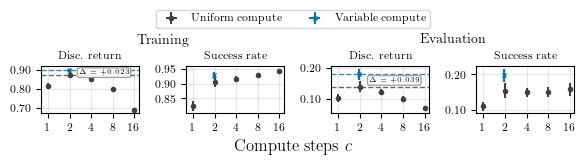

In [5]:
def plot_pareto_square_row(df, metrics, fname, trim=0, groups=None):
    """1xN row of square-aspect panels, one per (metric, panel title) in
    `metrics`, sharing one legend. With a single metric this is the
    standalone square figure. `groups` is a list of (title, [column indices])
    - each title is shared by (centered over) those columns."""
    nrows = 1
    ncols = len(metrics)
    figsize = set_size(doc_width_pt, fraction=0.95, subplots=(nrows, ncols), use_golden_ratio=False)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=False, squeeze=False)
    axes = axes.flatten()

    for col, (metric, panel_label) in enumerate(metrics):
        _draw_panel(axes[col], df, metric, panel_label, show_ylabel=False, trim=trim)
    # fig.supxlabel("Compute steps $c$", fontsize=FS["label"])
    fig.supxlabel("Compute steps $c$", y=0.15)

    by_label = {}
    for ax in np.ravel(axes):
        for h, l in zip(*ax.get_legend_handles_labels()):
            by_label.setdefault(l, h)
    fig.legend(
        list(by_label.values()),
        list(by_label.keys()),
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=min(len(by_label), ncols),
        borderaxespad=0.0,
        frameon=True,
        # fontsize=FS["legend"],
    )
    group_titles = [(title, [axes[i] for i in cols]) for title, cols in groups or []]
    finish_fig(fig, fname, group_titles=group_titles)
    if SAVE_FIGS:
        output_path = OUTPUT_DIR / f"analysis-iru.pdf"
        fig.savefig(output_path, format="pdf", bbox_inches="tight", dpi=600)
        print(f"Saved {output_path}")
    plt.show()

SQUARE_ROW_METRICS = [
    ("actor/episode_discounted_return/mean", "Disc. return"),
    ("actor/episode_return/mean", "Success rate"),
    ("evaluator/episode_discounted_return/mean", "Disc. return"),
    ("evaluator/episode_return/mean", "Success rate"),
]
SQUARE_ROW_GROUPS = [("Training", [0, 1]), ("Evaluation", [2, 3])]

plot_pareto_square_row(df, SQUARE_ROW_METRICS, "square_row", trim=TRIM_N, groups=SQUARE_ROW_GROUPS)